# Binding multimodal data using ImageBind and OpenVINO

Exploring the surrounding world, people get information using multiple senses, for example, seeing a busy street and hearing the sounds of car engines. ImageBind introduces an approach that brings machines one step closer to humans’ ability to learn simultaneously, holistically, and directly from many different forms of information. 
[ImageBind](https://github.com/facebookresearch/ImageBind) is the first AI model capable of binding data from six modalities at once, without the need for explicit supervision (the process of organizing and labeling raw data). By recognizing the relationships between these modalities — images and video, audio, text, depth, thermal, and inertial measurement units (IMUs) — this breakthrough helps advance AI by enabling machines to better analyze many different forms of information, together.

![ImageBind](https://user-images.githubusercontent.com/8495451/236859695-ffa13364-3e39-4d99-a8da-fbfab17f9a6b.gif)

In this tutorial, we consider how to convert and run ImageBind model using OpenVINO.

The tutorial consists of following steps:

1. Download the pre-trained model.
2. Prepare input data examples.
3. Convert the model to OpenVINO Intermediate Representation format (IR).
4. Run model inference and analyze results.

## About ImageBind

ImageBind, released in May 2023 by Meta Research, is an embedding model that combines data from six modalities: images and video, text, audio, thermal imaging, depth, and IMUs, which contain sensors including accelerometers and orientation monitors.
Using ImageBind, you can provide data in one modality – for example, audio – and find related documents in different modalities, such as video or images.

ImageBind was trained with pairs of data. Each pair mapped image data – including videos – to another modality, and the combined data was used to train an embedding model. ImageBind found that features for different modalities could be learned using the image data used in their training. A notable conclusion from ImageBind is that pairing images with another modality, then combining the results in the same embedding space is sufficient to create a multi-modal embedding model. 
More details about the model can be found in the model [repository](https://github.com/facebookresearch/ImageBind), [paper](https://arxiv.org/abs/2305.05665), and Meta AI [blog post](https://ai.facebook.com/blog/imagebind-six-modalities-binding-ai/).

Like all embedding models, there are many potential use cases for ImageBind, among them information retrieval, zero-shot classification, and usage created by ImageBind representation as input for downstream tasks (e.g. image generation). Some of the potential use-cases represented on the image below:

![usecases](https://user-images.githubusercontent.com/29454499/256303836-c8e7b311-0b7b-407c-8610-fd8a803e4197.png)

In this tutorial, we consider how to use ImageBind for multimodal zero-shot classification.


<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/image-bind/image-bind.ipynb" />






#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Instantiate PyTorch model](#Instantiate-PyTorch-model)
- [Prepare input data](#Prepare-input-data)
- [Convert Model to OpenVINO Intermediate Representation (IR) format](#Convert-Model-to-OpenVINO-Intermediate-Representation-(IR)-format)
    - [Select inference device](#Select-inference-device)
- [Zero-shot classification using ImageBind and OpenVINO](#Zero-shot-classification-using-ImageBind-and-OpenVINO)
    - [Text-Image classification](#Text-Image-classification)
    - [Text-Audio classification](#Text-Audio-classification)
    - [Image-Audio classification](#Image-Audio-classification)
- [Post-Training Quantization of ImageBind model with NNCF](#Post-Training-Quantization-of-ImageBind-model-with-NNCF)
    - [Prepare datasets](#Prepare-datasets)
    - [Apply quantization](#Apply-quantization)
        - [Quantize ImageBind model for vision modality.](#Quantize-ImageBind-model-for-vision-modality.)
        - [Quantize ImageBind model for text modality](#Quantize-ImageBind-model-for-text-modality)
        - [Quantize ImageBind model for audio modality](#Quantize-ImageBind-model-for-audio-modality)
    - [Compare results for the OpenVINO FP16 model and the quantized model](#Compare-results-for-the-OpenVINO-FP16-model-and-the-quantized-model)
        - [Select inference device](#Select-inference-device)
    - [Compare File Size](#Compare-File-Size)
    - [Compare inference time of the FP16 IR and quantized models](#Compare-inference-time-of-the-FP16-IR-and-quantized-models)
        - [Vision model](#Vision-model)
        - [Text model](#Text-model)
        - [Audio model](#Audio-model)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

## Prerequisites
[back to top ⬆️](#Table-of-contents:)


In [ ]:
%pip install -q "torch>=2.0.1" "torchvision>=0.15.2,<0.17.0" "torchaudio>=2.0.2" "matplotlib>=3.4" --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q datasets regex librosa soundfile pytorchvideo ftfy "timm>=0.6.7" einops fvcore "openvino>=2024.0.0" "nncf>=2.9.0" numpy scipy --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "matplotlib>=3.4"

In [ ]:
from pathlib import Path

repo_dir = Path("ImageBind")

if not repo_dir.exists():
    !git clone https://github.com/facebookresearch/ImageBind.git

%cd {repo_dir}

## Instantiate PyTorch model
[back to top ⬆️](#Table-of-contents:)

To start work with the model, we should instantiate the PyTorch model class. `imagebind_model.imagebind_huge(pretrained=True)` downloads model weights and creates a PyTorch model object for ImageBind. Currently, there is only one ImageBind model available for downloading, `imagebind_huge`, more details about it can be found in [model card](https://github.com/facebookresearch/ImageBind/blob/main/model_card.md).

> Please note, depending on internet connection speed, the model downloading process can take some time. It also requires at least 5 GB of free space on disk for saving model checkpoint.

In [ ]:
import imagebind.data as data
import torch
from imagebind.models import imagebind_model
from imagebind.models.imagebind_model import ModalityType

# Instantiate model
model = imagebind_model.imagebind_huge(pretrained=True)
model.eval();

## Prepare input data
[back to top ⬆️](#Table-of-contents:)

ImageBind works with data across 6 different modalities. Each of them requires its steps for preprocessing. `data` module is responsible for data reading and preprocessing for each modality.

* `data.load_and_transform_text` accepts a list of text labels and tokenizes them.
* `data.load_and_transform_vision_data` accepts paths to input images, reads them, resizes to save aspect ratio with smaller side size 224, performs center crop, and normalizes data into [0, 1] floating point range.
* `data.load_and_transofrm_audio_data` reads audio files from provided paths, splits it on samples, and computes [mel](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum) spectrogram.

In [4]:
# Prepare inputs

text_list = ["A car", "A bird", "A dog"]
image_paths = [
    ".assets/dog_image.jpg",
    ".assets/car_image.jpg",
    ".assets/bird_image.jpg",
]
audio_paths = [
    ".assets/dog_audio.wav",
    ".assets/bird_audio.wav",
    ".assets/car_audio.wav",
]

inputs = {
    ModalityType.TEXT: data.load_and_transform_text(text_list, "cpu"),
    ModalityType.VISION: data.load_and_transform_vision_data(image_paths, "cpu"),
    ModalityType.AUDIO: data.load_and_transform_audio_data(audio_paths, "cpu"),
}

## Convert Model to OpenVINO Intermediate Representation (IR) format
[back to top ⬆️](#Table-of-contents:)

OpenVINO supports PyTorch through Model Conversion API. You will use [model conversion Python API](https://docs.openvino.ai/2024/openvino-workflow/model-preparation.html) to convert model to IR format. The `ov.convert_model` function returns OpenVINO Model class instance ready to load on a device or save on a disk for next loading using `ov.save_model`.

ImageBind accepts data that represents different modalities simultaneously in any combinations, however, their processing is independent of each other. For avoiding losing flexibility passing data, we will export each modality encoder as an independent model.
The code below defines wrappers for the model to get only single-modality embeddings.

In [5]:
class ModelExporter(torch.nn.Module):
    def __init__(self, model, modality):
        super().__init__()
        self.model = model
        self.modality = modality

    def forward(self, data):
        return self.model({self.modality: data})

In [6]:
import openvino as ov

core = ov.Core()

### Select inference device
[back to top ⬆️](#Table-of-contents:)

select device from dropdown list for running inference using OpenVINO

In [7]:
import requests

r = requests.get(
    url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
)
open("notebook_utils.py", "w").write(r.text)

from notebook_utils import device_widget

device = device_widget()

device

Dropdown(description='Device:', index=3, options=('CPU', 'GPU.0', 'GPU.1', 'AUTO'), value='AUTO')

In [8]:
import openvino as ov

core = ov.Core()

ov_modality_models = {}

modalities = [ModalityType.TEXT, ModalityType.VISION, ModalityType.AUDIO]
for modality in modalities:
    export_dir = Path(f"image-bind-{modality}")
    file_name = f"image-bind-{modality}"
    export_dir.mkdir(exist_ok=True)
    ir_path = export_dir / f"{file_name}.xml"
    if not ir_path.exists():
        exportable_model = ModelExporter(model, modality)
        model_input = inputs[modality]
        ov_model = ov.convert_model(exportable_model, example_input=model_input)
        ov.save_model(ov_model, ir_path)
    else:
        ov_model = core.read_model(ir_path)
    ov_modality_models[modality] = core.compile_model(ov_model, device.value)

## Zero-shot classification using ImageBind and OpenVINO
[back to top ⬆️](#Table-of-contents:)

In zero-shot classification, a piece of data is embedded and fed to the model to retrieve a label that corresponds with the contents of the data. In the case of ImageBind, you can classify audio, images, and information in the other supported modalities. We already discussed how to perform zero-shot image classification using the CLIP model (please check this [notebook](../clip-zero-shot-image-classification/clip-zero-shot-image-classification.ipynb) for details), capabilities of ImageBind for this task wider, because it allows using any combinations of supported modalities for classification.

To perform zero-shot classification using ImageBind we should perform the following steps:

1. Preprocess data batch for requested modalities (one modality in our case treated as a data source, other - as a label).
2. Calculate embeddings for each modality.
3. Find dot-product between embeddings vectors to get probabilities matrix.
4. Obtain the label with the highest probability for mapping the source into label space.

We already preprocessed data in previous step, now, we should run model inference for getting embeddings.

In [9]:
embeddings = {}
for modality in modalities:
    embeddings[modality] = ov_modality_models[modality](inputs[modality])[ov_modality_models[modality].output(0)]

The probability matrix shows the correspondence between source embeddings and label embeddings, it is a 2D matrix, where x-dimension represents label-modality data and y-dimension - source-modality data. It can be calculated as a dot-product between embeddings vectors and normalized into the [0,1] range using softmax. Then a higher score on the intersection between x and y labels, then higher confidence that they represent the same object.

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import softmax


def visualize_prob_matrix(matrix, x_label, y_label):
    fig, ax = plt.subplots()
    ax.matshow(matrix, cmap="winter")

    for (i, j), z in np.ndenumerate(matrix):
        ax.text(j, i, "{:0.3f}".format(z), ha="center", va="center")
        ax.set_xticks(range(len(x_label)), x_label)
        ax.set_yticks(range(len(y_label)), y_label)


image_list = [img.split("/")[-1] for img in image_paths]
audio_list = [audio.split("/")[-1] for audio in audio_paths]

### Text-Image classification
[back to top ⬆️](#Table-of-contents:)


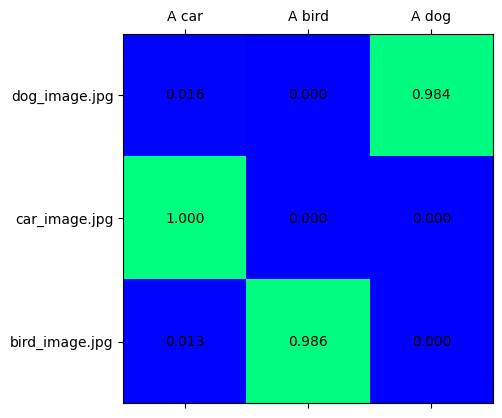

In [11]:
text_vision_scores = softmax(embeddings[ModalityType.VISION] @ embeddings[ModalityType.TEXT].T, axis=-1)

visualize_prob_matrix(text_vision_scores, text_list, image_list)

### Text-Audio classification
[back to top ⬆️](#Table-of-contents:)


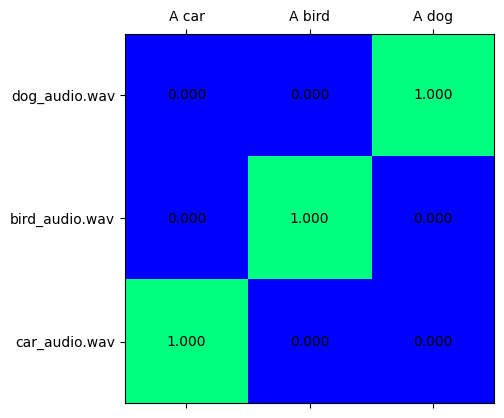

In [12]:
text_audio_scores = softmax(embeddings[ModalityType.AUDIO] @ embeddings[ModalityType.TEXT].T, axis=-1)

visualize_prob_matrix(text_audio_scores, text_list, audio_list)

### Image-Audio classification
[back to top ⬆️](#Table-of-contents:)


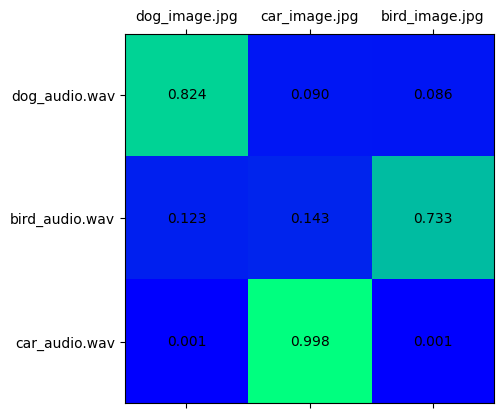

In [13]:
audio_vision_scores = softmax(embeddings[ModalityType.VISION] @ embeddings[ModalityType.AUDIO].T, axis=-1)

visualize_prob_matrix(audio_vision_scores, image_list, audio_list)

Putting all together, we can match text, image, and sound for our data.

Predicted label: A car 
probability for image - 1.000
probability for audio - 1.000


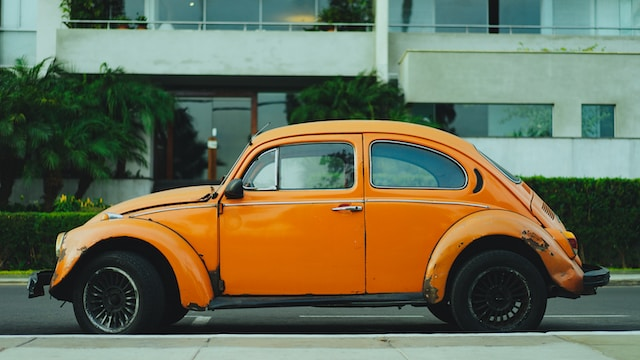

In [14]:
import IPython.display as ipd
from PIL import Image

text_image_ids = np.argmax(text_vision_scores, axis=0)
text_audio_ids = np.argmax(text_audio_scores, axis=0)
print(
    f"Predicted label: {text_list[0]} \nprobability for image - {text_vision_scores[text_image_ids[0], 0]:.3f}\nprobability for audio - {text_audio_scores[0, text_audio_ids[0]]:.3f}"
)
display(Image.open(image_paths[text_image_ids[0]]))
ipd.Audio(audio_paths[text_audio_ids[0]])

Predicted label: A bird 
probability for image - 0.986
probability for audio - 1.000


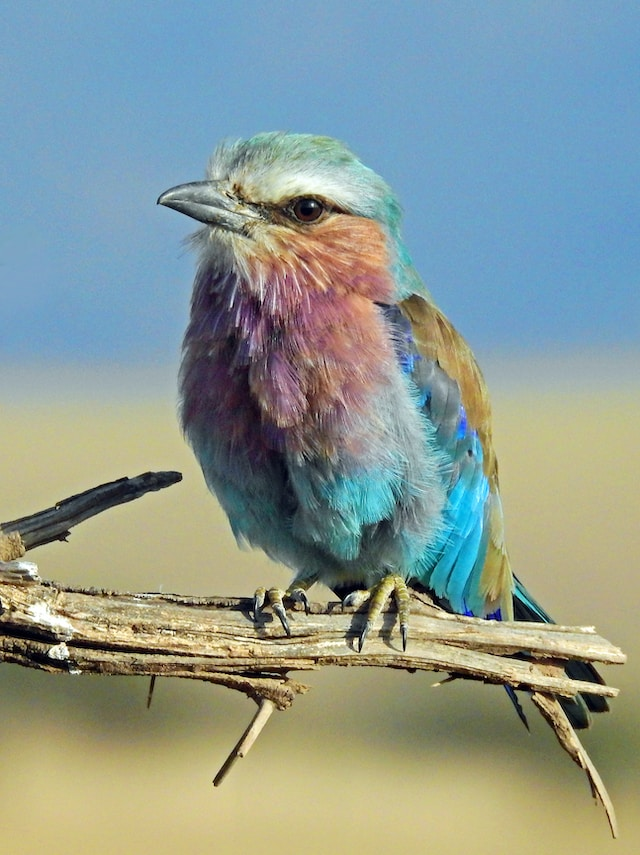

In [15]:
print(
    f"Predicted label: {text_list[1]} \nprobability for image - {text_vision_scores[text_image_ids[1], 1]:.3f}\nprobability for audio - {text_audio_scores[1, text_audio_ids[1]]:.3f}"
)
display(Image.open(image_paths[text_image_ids[1]]))
ipd.Audio(audio_paths[text_audio_ids[1]])

Predicted label: A dog 
probability for image - 0.984
probability for audio - 1.000


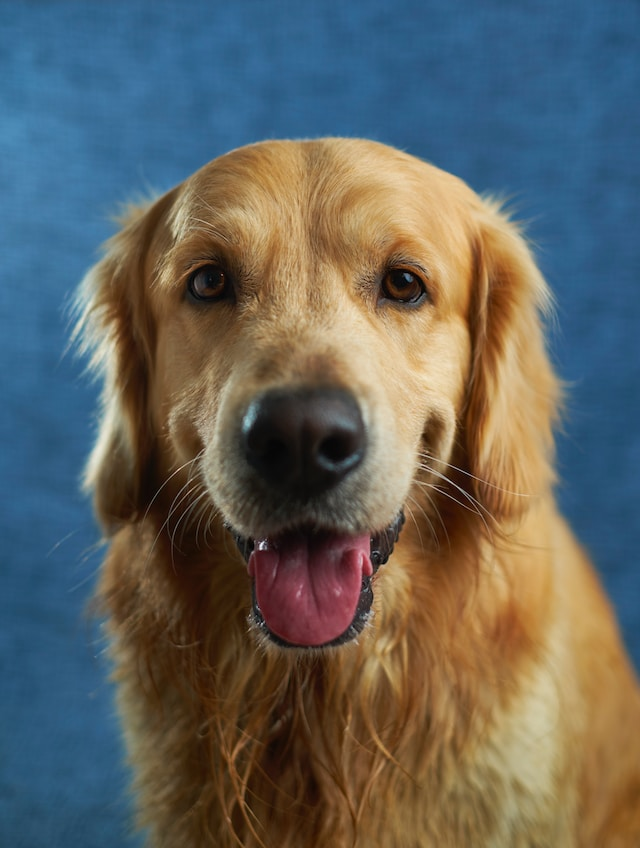

In [16]:
print(
    f"Predicted label: {text_list[2]} \nprobability for image - {text_vision_scores[text_image_ids[2], 2]:.3f}\nprobability for audio - {text_audio_scores[2, text_audio_ids[2]]:.3f}"
)
display(Image.open(image_paths[text_image_ids[2]]))
ipd.Audio(audio_paths[text_audio_ids[2]])

## Post-Training Quantization of ImageBind model with NNCF
[back to top ⬆️](#Table-of-contents:)

The goal of this part of tutorial is to demonstrate how to speed up the model by applying 8-bit post-training quantization from [NNCF](https://github.com/openvinotoolkit/nncf/) (Neural Network Compression Framework) and infer quantized model via OpenVINO™ Toolkit. 

The optimization process contains the following steps:
1. Prepare quantization dataset
2. Quantize OpenVINO model with NNCF.
3. Compare probability matrices between converted and quantized models on input data examples.
4. Compare model size of converted and quantized models.
5. Compare performance of converted and quantized models.

In [17]:
modalities = [ModalityType.TEXT, ModalityType.VISION, ModalityType.AUDIO]
fp_model_paths = {modality: Path(f"image-bind-{modality}") / f"image-bind-{modality}.xml" for modality in modalities}
int8_model_paths = {modality: Path(f"image-bind-{modality}") / f"image-bind-{modality}_int8.xml" for modality in modalities}

### Prepare datasets
[back to top ⬆️](#Table-of-contents:)

The [Conceptual Captions](https://ai.google.com/research/ConceptualCaptions/) dataset consisting of ~3.3M images annotated with captions. Dataset is used to quantize image and text models.

In [18]:
import imagebind.data as data
import os
import requests
import tempfile

from requests.packages.urllib3.exceptions import InsecureRequestWarning

requests.packages.urllib3.disable_warnings(InsecureRequestWarning)


def check_text_data(data):
    """
    Check if the given data is text-based.
    """
    if isinstance(data, str):
        return True
    if isinstance(data, list):
        return all(isinstance(x, str) for x in data)
    return False


def collate_fn(examples, image_column="image_url", text_column="caption"):
    """
    Collates examples into a batch for processing.
    Preprocesses each example by loading and transforming image and text data.
    Checks if the text data in the example is valid by calling the `check_text_data` function.
    Downloads the image specified by the URL in the image_column of the example dictionary.
    Constructs and returns a dictionary representing the collated batch with the following keys:
       - "pixel_values": The pixel values of the preprocessed example.
       - "input_ids": The transformed text data of the preprocessed example.
    """
    assert len(examples) == 1
    example = examples[0]
    if not check_text_data(example[text_column]):
        raise ValueError("Text data is not valid")

    url = example[image_column]
    with tempfile.TemporaryDirectory() as tempdir:
        f_name = os.path.join(tempdir, "image.jpg")
        try:
            response = requests.get(url, verify=False, timeout=20)
            with open(f_name, "wb") as file:
                file.write(response.content)
            pixel_values = data.load_and_transform_vision_data([f_name], "cpu")
        except Exception:
            print(f"Can't load image from url: {url}")
            return None

    text = data.load_and_transform_text([example[text_column]], "cpu")

    return {"pixel_values": pixel_values, "input_ids": text}

In [19]:
from datasets import load_dataset
import itertools
import torch
from tqdm.notebook import tqdm


def collect_vision_text_data(dataloader, init_steps):
    """
    This function collects vision and text data from a dataloader for a specified number of initialization steps.
    It iterates over the dataloader, fetching batches and storing the relevant vision and text data.
    Returns a tuple containing the collected vision_data and text_data lists.
    """
    text_data = []
    vision_data = []
    print(f"Fetching {init_steps} for the initialization...")
    counter = 0
    for batch in tqdm(dataloader):
        if counter == init_steps:
            break
        with torch.no_grad():
            if batch:
                counter += 1
                text_data.append(batch["input_ids"].to("cpu"))
                vision_data.append(batch["pixel_values"].to("cpu"))
    return vision_data, text_data


def prepare_vision_text_dataset(opt_init_steps=50):
    """
    Prepares a vision-text dataset for quantization by collecting vision and text data.
    """
    dataset = load_dataset("google-research-datasets/conceptual_captions", streaming=False, trust_remote_code=True)
    train_dataset = dataset["train"].shuffle(seed=0)
    dataloader = torch.utils.data.DataLoader(train_dataset, collate_fn=collate_fn, batch_size=1)
    vision_data, text_data = collect_vision_text_data(dataloader, opt_init_steps)
    return vision_data, text_data

The [`ESC-50`](https://github.com/karolpiczak/ESC-50) dataset is used to quantize the audio modality of the ImageBind model.
Dataset is a labeled collection of 2000 environmental audio recordings suitable for benchmarking methods of environmental sound classification.
The dataset consists of 5-second-long recordings organized into 50 semantic classes.

In [20]:
import numpy as np
import torchaudio


def collect_audio_data(dataloader, init_steps=300):
    """
    This function collects audio data from a dataloader for a specified number of initialization steps.
    It iterates over the dataloader, fetching batches and storing them in a list.
    """
    audio_data = []
    for _, batch in tqdm(zip(range(init_steps), itertools.islice(dataloader, 0, init_steps))):
        with torch.no_grad():
            audio_data.append(batch)
    return audio_data


def prepare_audio_dataset():
    """
    Prepares an "ashraq/esc50" audio dataset for quantization by collecting audio data.
    Collects audio data from the dataloader by calling the `collect_audio_data` function.
    Returns a list containing the collected calibration audio data batches.
    """
    audio_dataset = load_dataset("ashraq/esc50", streaming=True, trust_remote_code=True)
    train_dataset = audio_dataset["train"].shuffle(seed=42, buffer_size=1000)

    def collate_fn(examples):
        assert len(examples) == 1
        with tempfile.TemporaryDirectory() as tempdir:
            f_name = os.path.join(tempdir, "audio.wav")
            audio_data = examples[0]["audio"]["array"]
            sample_rate = examples[0]["audio"]["sampling_rate"]
            audio_data = torch.from_numpy(audio_data).to(torch.float32).unsqueeze(0)
            torchaudio.save(f_name, audio_data, sample_rate)
            return data.load_and_transform_audio_data([f_name], "cpu")

    dataloader = torch.utils.data.DataLoader(train_dataset, collate_fn=collate_fn, batch_size=1)
    calibration_data = collect_audio_data(dataloader)
    return calibration_data

In [ ]:
vision_data, text_data = [], []

if not int8_model_paths[ModalityType.TEXT].exists() or not int8_model_paths[ModalityType.VISION].exists():
    vision_data, text_data = prepare_vision_text_dataset()

### Apply quantization
[back to top ⬆️](#Table-of-contents:)

In [22]:
import logging
import nncf
import openvino as ov

nncf.set_log_level(logging.ERROR)

core = ov.Core()


def quantize_openvino_model(modality, calibration_data):
    model_path = fp_model_paths[modality]
    model = core.read_model(model_path)
    quantized_model = nncf.quantize(
        model=model,
        calibration_dataset=calibration_data,
        model_type=nncf.ModelType.TRANSFORMER,
    )
    ov.save_model(quantized_model, int8_model_paths[modality])
    return quantized_model

INFO:nncf:NNCF initialized successfully. Supported frameworks detected: torch, tensorflow, onnx, openvino


#### Quantize ImageBind model for vision modality.
[back to top ⬆️](#Table-of-contents:)

> **NOTE**: Quantization is time and memory consuming operation. Running quantization code below may take a long time.

In [ ]:
if not int8_model_paths[ModalityType.VISION].exists():
    if len(vision_data) == 0:
        raise RuntimeError("Calibration dataset is empty. Please check internet connection and try to download images manually from the URLs above.")

    vision_dataset = nncf.Dataset(vision_data)
    vision_quantized_model = quantize_openvino_model(modality=ModalityType.VISION, calibration_data=vision_dataset)

#### Quantize ImageBind model for text modality
[back to top ⬆️](#Table-of-contents:)

In [ ]:
if not int8_model_paths[ModalityType.TEXT].exists():
    text_dataset = nncf.Dataset(text_data)
    text_quantized_model = quantize_openvino_model(modality=ModalityType.TEXT, calibration_data=text_dataset)

#### Quantize ImageBind model for audio modality
[back to top ⬆️](#Table-of-contents:)

In [ ]:
if not int8_model_paths[ModalityType.AUDIO].exists():
    audio_calibration_data = prepare_audio_dataset()
    audio_dataset = nncf.Dataset(audio_calibration_data)
    audio_quantized_model = quantize_openvino_model(modality=ModalityType.AUDIO, calibration_data=audio_dataset)

NNCF also supports quantization-aware training, and other algorithms than quantization.
See the [NNCF documentation](https://github.com/openvinotoolkit/nncf/#documentation) in the NNCF repository for more information.

### Compare results for the OpenVINO FP16 model and the quantized model
[back to top ⬆️](#Table-of-contents:)

Compare the probability matrices for `FP16` and `INT8` models.

In [26]:
# Prepare inputs

text_list = ["A car", "A bird", "A dog"]
image_paths = [
    ".assets/dog_image.jpg",
    ".assets/car_image.jpg",
    ".assets/bird_image.jpg",
]
audio_paths = [
    ".assets/dog_audio.wav",
    ".assets/bird_audio.wav",
    ".assets/car_audio.wav",
]

inputs = {
    ModalityType.TEXT: data.load_and_transform_text(text_list, "cpu"),
    ModalityType.VISION: data.load_and_transform_vision_data(image_paths, "cpu"),
    ModalityType.AUDIO: data.load_and_transform_audio_data(audio_paths, "cpu"),
}

#### Select inference device
[back to top ⬆️](#Table-of-contents:)

select device from dropdown list for running inference using OpenVINO

In [27]:
device

Dropdown(description='Device:', index=3, options=('CPU', 'GPU.0', 'GPU.1', 'AUTO'), value='AUTO')

In [28]:
embeddings = {}
for modality in modalities:
    ov_model = core.compile_model(fp_model_paths[modality], device.value)
    embeddings[modality] = ov_model(inputs[modality])[0]

quantized_embeddings = {}
for modality in modalities:
    model = core.compile_model(int8_model_paths[modality], device.value)
    quantized_embeddings[modality] = model(inputs[modality])[0]

In [29]:
def visualize_prob_matrices(fp_matrix, int_matrix, x_label, y_label):
    fig, ax = plt.subplots(1, 2)
    for i, matrix in enumerate([fp_matrix, int_matrix]):
        ax[i].matshow(matrix, cmap="winter")

        for (k, j), z in np.ndenumerate(matrix):
            ax[i].title.set_text("FP16 probs" if i == 0 else "INT8 probs")
            ax[i].text(j, k, "{:0.3f}".format(z), ha="center", va="center")
            ax[i].set_xticks(range(len(x_label)), x_label)
            ax[i].set_yticks(range(len(y_label)), y_label)
    fig.tight_layout()


image_list = [img.split("/")[-1] for img in image_paths]
audio_list = [audio.split("/")[-1] for audio in audio_paths]

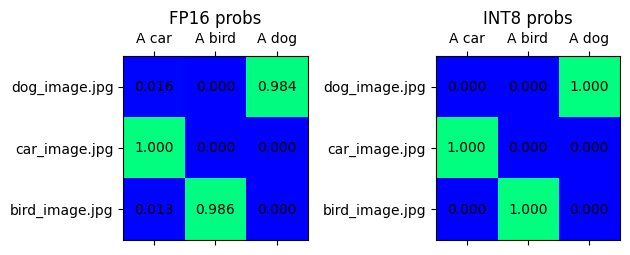

In [30]:
fp_text_vision_scores = softmax(embeddings[ModalityType.VISION] @ embeddings[ModalityType.TEXT].T, axis=-1)
int_text_vision_scores = softmax(
    quantized_embeddings[ModalityType.VISION] @ quantized_embeddings[ModalityType.TEXT].T,
    axis=-1,
)

visualize_prob_matrices(fp_text_vision_scores, int_text_vision_scores, text_list, image_list)

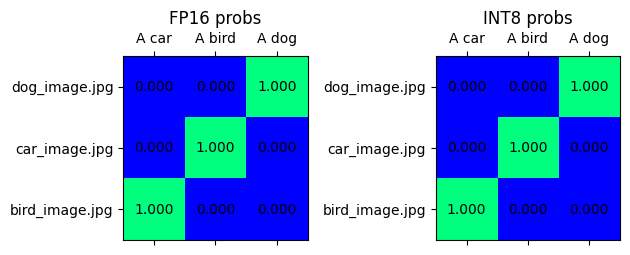

In [31]:
fp_text_audio_scores = softmax(embeddings[ModalityType.AUDIO] @ embeddings[ModalityType.TEXT].T, axis=-1)
int_text_audio_scores = softmax(
    quantized_embeddings[ModalityType.AUDIO] @ quantized_embeddings[ModalityType.TEXT].T,
    axis=-1,
)

visualize_prob_matrices(fp_text_audio_scores, int_text_audio_scores, text_list, image_list)

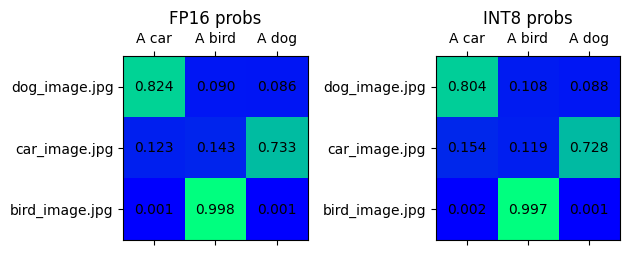

In [32]:
fp_audio_vision_scores = softmax(embeddings[ModalityType.VISION] @ embeddings[ModalityType.AUDIO].T, axis=-1)
int_audio_vision_scores = softmax(
    quantized_embeddings[ModalityType.VISION] @ quantized_embeddings[ModalityType.AUDIO].T,
    axis=-1,
)

visualize_prob_matrices(fp_audio_vision_scores, int_audio_vision_scores, text_list, image_list)

### Compare File Size
[back to top ⬆️](#Table-of-contents:)

In [33]:
def calculate_compression_rate(modality):
    fp16_ir_model_size = Path(fp_model_paths[modality]).with_suffix(".bin").stat().st_size / 1024
    quantized_model_size = Path(int8_model_paths[modality]).with_suffix(".bin").stat().st_size / 1024
    print(f"Modality: {modality}")
    print(f"    * FP16 IR model size: {fp16_ir_model_size:.2f} KB")
    print(f"    * INT8 model size: {quantized_model_size:.2f} KB")
    print(f"    * Model compression rate: {fp16_ir_model_size / quantized_model_size:.3f}")


for modality in modalities:
    calculate_compression_rate(modality)

Modality: text
    * FP16 IR model size: 691481.69 KB
    * INT8 model size: 347006.66 KB
    * Model compression rate: 1.993
Modality: vision
    * FP16 IR model size: 1235995.15 KB
    * INT8 model size: 620132.79 KB
    * Model compression rate: 1.993
Modality: audio
    * FP16 IR model size: 168429.15 KB
    * INT8 model size: 84818.40 KB
    * Model compression rate: 1.986


### Compare inference time of the FP16 IR and quantized models
[back to top ⬆️](#Table-of-contents:)

To measure the inference performance of the `FP16` and `INT8` models, we use median inference time on calibration dataset.
So we can approximately estimate the speed up of the dynamic quantized models.


> **NOTE**: For the most accurate performance estimation, it is recommended to run `benchmark_app` in a terminal/command prompt after closing other applications with static shapes.

In [34]:
import time


def calculate_inference_time(model_path, calibration_data):
    model = core.compile_model(model_path)
    output_layer = model.output(0)
    inference_time = []
    for batch in calibration_data:
        start = time.perf_counter()
        _ = model(batch)[output_layer]
        end = time.perf_counter()
        delta = end - start
        inference_time.append(delta)
    return np.median(inference_time)

#### Vision model
[back to top ⬆️](#Table-of-contents:)

In [35]:
fp16_latency = calculate_inference_time(fp_model_paths[ModalityType.VISION], vision_data)
int8_latency = calculate_inference_time(int8_model_paths[ModalityType.VISION], vision_data)
print(f"Performance speed up: {fp16_latency / int8_latency:.3f}")

Performance speed up: 2.375


#### Text model
[back to top ⬆️](#Table-of-contents:)

In [36]:
fp16_latency = calculate_inference_time(fp_model_paths[ModalityType.TEXT], text_data)
int8_latency = calculate_inference_time(int8_model_paths[ModalityType.TEXT], text_data)
print(f"Performance speed up: {fp16_latency / int8_latency:.3f}")

Performance speed up: 1.492


#### Audio model
[back to top ⬆️](#Table-of-contents:)

In [37]:
fp16_latency = calculate_inference_time(fp_model_paths[ModalityType.AUDIO], audio_calibration_data)
int8_latency = calculate_inference_time(int8_model_paths[ModalityType.AUDIO], audio_calibration_data)
print(f"Performance speed up: {fp16_latency / int8_latency:.3f}")

Performance speed up: 5.770
